<a href="https://colab.research.google.com/github/nicole062797-star/TFM-fin-de-master-Ciencia-de-datos/blob/main/Calculo_de_tasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Configuramos el estilo visual de los gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
#Montamos Google Drive para acceder a los archivos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta = "/content/drive/MyDrive/TFM/dataset_etl_final.csv"
df = pd.read_csv(ruta)

/tmp/ipykernel_23711/3353491563.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


In [ ]:
#Visualizamos las primeras filas para comprobar que la carga fue correcta
df.head()

,numero_de_emision,identificacion,periodo,tipo_de_posesion,descripcion_posesion,categoria,valor,valor_posesion_avaluo_patrimonio,valor_de_predio_emitido_2023,fecha_de_emision_2023,...,dias_hasta_pago_2023,dias_hasta_pago_2024,dias_hasta_pago_2025,estado_pago_2023,estado_pago_2024,estado_pago_2025,moroso_2023,moroso_2024,moroso_2025,anio
0,2437191,100161744,Año 2026,LOCAL COMERCIAL,HERRERA MANOBANDA WASHINGTON OLMEDO,Comercial,9.44,800.0,11.25,2023-10-03,...,70.0,0.0,109.0,Pagado,Pagado,Pagado,1,0,1,2026.0
1,2436174,101812238,Año 2026,LOCAL COMERCIAL,COMERCIAL PRIKA,Comercial,23.52,25000.0,124.25,2023-01-11,...,0.0,0.0,0.0,Pagado,Pagado,Pagado,0,0,0,2026.0
2,2437327,103102711,Año 2026,LOCAL COMERCIAL,JOYERIA ORO VERDE,Comercial,12.24,2410.0,11.25,2023-10-04,...,0.0,0.0,3.0,Pagado,Pagado,Pagado,0,0,0,2026.0
3,2439430,105594303,Año 2026,LOCAL COMERCIAL,TECNIAUTO,Comercial,9.44,700.0,24.56,2023-12-31,...,275.0,0.0,0.0,Pagado,Pagado,Pagado,1,0,0,2026.0
4,2440078,201273042,Año 2026,LOCAL COMERCIAL,VIVERO VILLAFUERTE,Comercial,9.44,1000.0,0.00,NaN,...,NaN,NaN,82.0,No pagado,No pagado,Pagado,0,0,1,2026.0


In [ ]:
#Revisamos el tamaño del dataset
df.shape

(56350, 27)

In [ ]:
#Revisamos los nombres de las columnas disponibles
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025',
       'dias_hasta_pago_2023', 'dias_hasta_pago_2024', 'dias_hasta_pago_2025',
       'estado_pago_2023', 'estado_pago_2024', 'estado_pago_2025',
       'moroso_2023', 'moroso_2024', 'moroso_2025', 'anio'],
      dtype='object')

In [ ]:
#Revisamos los tipos de datos para conocer la estructura del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56350 entries, 0 to 56349
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   numero_de_emision                 56350 non-null  int64  
 1   identificacion                    56350 non-null  object 
 2   periodo                           56350 non-null  object 
 3   tipo_de_posesion                  56350 non-null  object 
 4   descripcion_posesion              56350 non-null  object 
 5   categoria                         56350 non-null  object 
 6   valor                             56350 non-null  float64
 7   valor_posesion_avaluo_patrimonio  38231 non-null  float64
 8   valor_de_predio_emitido_2023      56350 non-null  float64
 9   fecha_de_emision_2023             45201 non-null  object 
 10  fecha_de_liquidacion_2023         40384 non-null  object 
 11  valor_de_predio_emitido_2024      56350 non-null  float64
 12  fech

In [ ]:
#Revisamos las categorías del dataset
df["categoria"].value_counts()

,count
categoria,
Residencial Rural,33996
Residencial Urbano 1,7915
Residencial Urbano 2,7040
Comercial,5363
Residencial Urbano 3,2036


In [ ]:
#Normalizamos la columna categoria para evitar errores de texto
df["categoria"] = df["categoria"].str.upper().str.strip()

In [ ]:
#Verificamos
df["categoria"].value_counts()

,count
categoria,
RESIDENCIAL RURAL,33996
RESIDENCIAL URBANO 1,7915
RESIDENCIAL URBANO 2,7040
COMERCIAL,5363
RESIDENCIAL URBANO 3,2036


In [ ]:
#Clasificamos el tipo de tasa según la categoría
def tipo_tasa(row):

    if "RURAL" in row["categoria"]:
        return "RURAL"

    elif "URBANO 1" in row["categoria"]:
        return "URBANO 1"

    elif "URBANO 2" in row["categoria"]:
        return "URBANO 2"

    elif "URBANO 3" in row["categoria"]:
        return "URBANO 3"

    elif "COMERCIAL" in row["categoria"]:
        return "COMERCIAL"

    elif "INDUSTRIAL" in row["categoria"]:
        return "INDUSTRIAL"

    else:
        return "OTRO"

df["tipo_tasa"] = df.apply(tipo_tasa, axis=1)

In [ ]:
df["tipo_tasa"].value_counts()

,count
tipo_tasa,
RURAL,33996
URBANO 1,7915
URBANO 2,7040
COMERCIAL,5363
URBANO 3,2036


Según la ordenanza municipal, el valor fijo o tarifa base es de $1.11 para la emision de la tasa la basura en predios urbanos y rurales

Cálculo de la tasa para predios rurales

In [ ]:
#Calculamos la tasa rural aplicando la condición de la ordenanza
def calcular_tasa_rural(row):
    #Verificamos si el predio es rural
    if row["tipo_tasa"] == "RURAL":
        #Para predios rurales, la tasa es igual al valor fijo
        return 1.11

    else:
        #No aplica para otras categorías
        return 0

In [ ]:
#Creamos la columna de tasa rural
df["tasa_rural"] = df.apply(calcular_tasa_rural, axis=1)

In [ ]:
#Revisamos que solo los rurales tengan valor
df.groupby("tipo_tasa")["tasa_rural"].unique()

,tasa_rural
tipo_tasa,
COMERCIAL,[0.0]
RURAL,[1.11]
URBANO 1,[0.0]
URBANO 2,[0.0]
URBANO 3,[0.0]


In [ ]:
#Miramos los registros rurales
df[df["tipo_tasa"] == "RURAL"][["tipo_tasa", "tasa_rural"]].head()

,tipo_tasa,tasa_rural
5363,RURAL,1.11
5364,RURAL,1.11
5366,RURAL,1.11
5370,RURAL,1.11
5374,RURAL,1.11


In [ ]:
#Miramos los valores unicos
df[df["tipo_tasa"] == "RURAL"]["tasa_rural"].unique()

array([1.11])

In [ ]:
#Validamos
(df[df["tipo_tasa"] == "RURAL"]["tasa_rural"] == 1.11).all()

np.True_

In [ ]:
#Total de predios rurales
total_rurales = df[df["tipo_tasa"] == "RURAL"].shape[0]
total_rurales

33996

In [ ]:
#Valor mensual total
total_mensual = df[df["tipo_tasa"] == "RURAL"]["tasa_rural"].sum()
total_mensual

np.float64(37735.56)

In [ ]:
#Valor anual (12 meses)
total_anual = total_mensual * 12
total_anual

np.float64(452826.72)

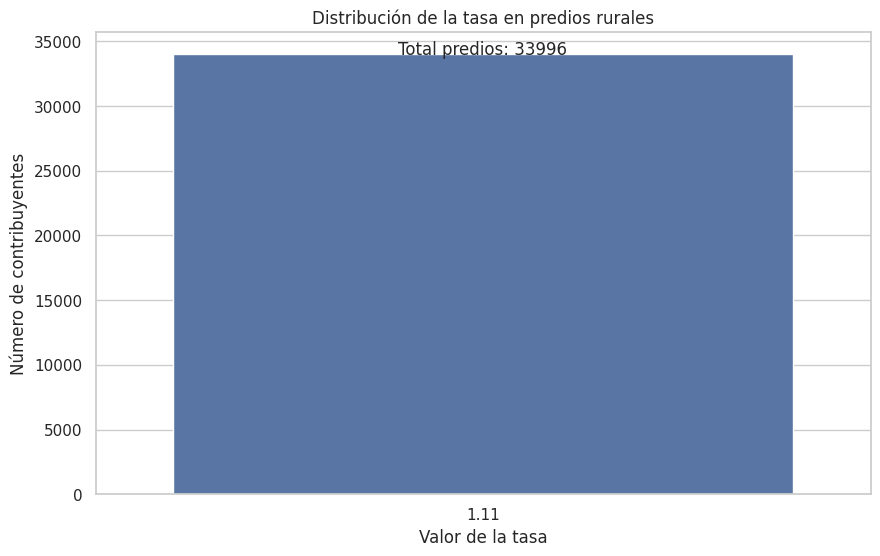

In [ ]:
#graficamos
rural_df = df[df["tipo_tasa"] == "RURAL"]

sns.countplot(
    data=rural_df,
    x="tasa_rural"
)

plt.title("Distribución de la tasa en predios rurales")
plt.xlabel("Valor de la tasa")
plt.ylabel("Número de contribuyentes")

plt.text(
    0,
    rural_df.shape[0],
    f"Total predios: {rural_df.shape[0]}",
    ha='center'
)

plt.show()

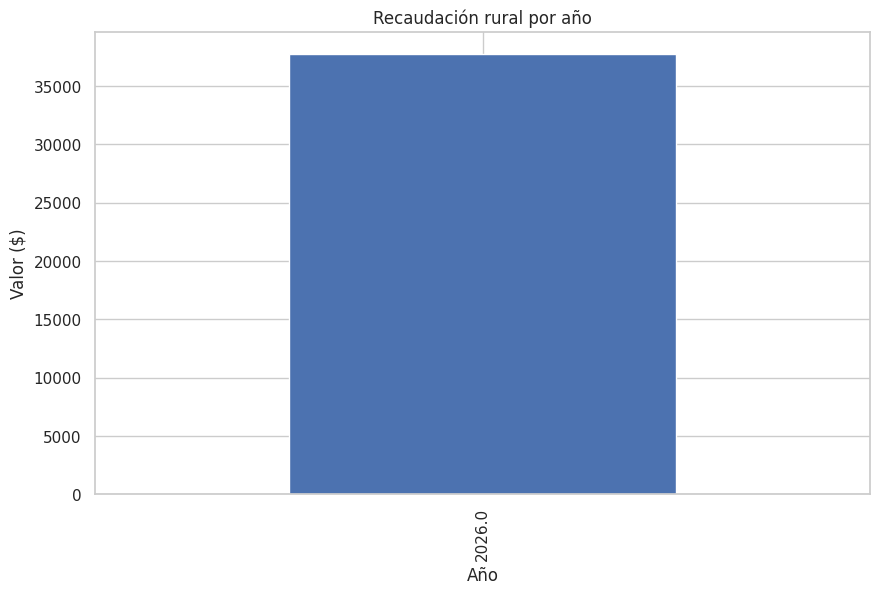

In [ ]:
rural_por_anio = df[df["tipo_tasa"] == "RURAL"].groupby("anio")["tasa_rural"].sum()

rural_por_anio.plot(kind="bar")

plt.title("Recaudación rural por año")
plt.ylabel("Valor ($)")
plt.xlabel("Año")

plt.show()

Se identificó un total de 33.996 predios rurales, los cuales presentan una tasa constante mensual de 1.11 dólares. A partir de este valor, se estimó la recaudación mensual y anual del municipio para esta categoría, evidenciando un comportamiento estable debido a la naturaleza fija de la tasa.

Calculamos la tasa comercial que esta en base al valor del patrimonio la categoria

In [ ]:
#Borro columnas para recalcular
columnas_borrar = [
    "categoria_comercial",
    "porcentaje_sbu_comercial",
    "tasa_comercial"
]

df = df.drop(columns=[c for c in columnas_borrar if c in df.columns])

In [ ]:
# Definimos el Salario Básico Unificado en base al año anterior 2025
sbu_2026 = 470

In [ ]:
#Creamos una función para asignar el porcentaje SBU según el patrimoni
def calcular_categoria_comercial(row):

    patrimonio = row["valor_posesion_avaluo_patrimonio"]
     #Verificamos que el registro sea comercial
    if row["tipo_tasa"] != "COMERCIAL":
        return ""

    if patrimonio <= 1000:
        return "Comercial 1"
    elif patrimonio <= 2500:
        return "Comercial 2"
    elif patrimonio <= 5000:
        return "Comercial 3"
    elif patrimonio <= 10000:
        return "Comercial 4"
    elif patrimonio <= 20000:
        return "Comercial 5"
    elif patrimonio <= 40000:
        return "Comercial 6"
    elif patrimonio <= 80000:
        return "Comercial 7"
    elif patrimonio <= 160000:
        return "Comercial 8"
    elif patrimonio <= 320000:
        return "Comercial 9"
    elif patrimonio <= 640000:
        return "Comercial 10"
    elif patrimonio <= 1280000:
        return "Comercial 11"
    elif patrimonio <= 2295666:
        return "Comercial 12"
    else:
        return "Comercial 13"

df["categoria_comercial"] = df.apply(calcular_categoria_comercial, axis=1)

In [ ]:
df[df["tipo_tasa"] == "COMERCIAL"]["categoria_comercial"].value_counts()

,count
categoria_comercial,
Comercial 1,2948
Comercial 3,997
Comercial 2,589
Comercial 4,532
Comercial 5,149
Comercial 6,64
Comercial 7,49
Comercial 8,16
Comercial 9,12


In [ ]:
#Asignamos el porcentaje SBU
def porcentaje_sbu(row):

    if row["tipo_tasa"] != "COMERCIAL":
        return 0

    cat = row["categoria_comercial"]

    if cat == "Comercial 1":
        return 0.250
    elif cat == "Comercial 2":
        return 0.325
    elif cat == "Comercial 3":
        return 0.400
    elif cat == "Comercial 4":
        return 0.475
    elif cat == "Comercial 5":
        return 0.550
    elif cat == "Comercial 6":
        return 0.625
    elif cat == "Comercial 7":
        return 1.375
    elif cat == "Comercial 8":
        return 2.125
    elif cat == "Comercial 9":
        return 2.875
    elif cat == "Comercial 10":
        return 3.625
    elif cat == "Comercial 11":
        return 11.125
    elif cat == "Comercial 12":
        return 18.625
    else:
        return 26.125

df["porcentaje_sbu_comercial"] = df.apply(porcentaje_sbu, axis=1)

In [ ]:
#Verificamos
df[df["tipo_tasa"] == "COMERCIAL"][
    ["categoria_comercial", "porcentaje_sbu_comercial"]
].drop_duplicates().sort_values("porcentaje_sbu_comercial")

,categoria_comercial,porcentaje_sbu_comercial
0,Comercial 1,0.250
2,Comercial 2,0.325
5,Comercial 3,0.400
20,Comercial 4,0.475
21,Comercial 5,0.550
1,Comercial 6,0.625
11,Comercial 7,1.375
1558,Comercial 8,2.125
23,Comercial 9,2.875
2343,Comercial 10,3.625


In [ ]:
#Calculamos la tasa comercial
sbu = 470
df["tasa_comercial"] = (
    sbu * df["porcentaje_sbu_comercial"] / 100
).round(2)

In [ ]:
#Verificamos
df[df["tipo_tasa"] == "COMERCIAL"][
    [
        "categoria_comercial",
        "porcentaje_sbu_comercial",
        "tasa_comercial"
    ]
].drop_duplicates().sort_values("porcentaje_sbu_comercial")

,categoria_comercial,porcentaje_sbu_comercial,tasa_comercial
0,Comercial 1,0.250,1.18
2,Comercial 2,0.325,1.53
5,Comercial 3,0.400,1.88
20,Comercial 4,0.475,2.23
21,Comercial 5,0.550,2.58
1,Comercial 6,0.625,2.94
11,Comercial 7,1.375,6.46
1558,Comercial 8,2.125,9.99
23,Comercial 9,2.875,13.51
2343,Comercial 10,3.625,17.04


Para los contribuyentes comerciales, se implementó un modelo basado en el Salario Básico Unificado (SBU), donde la tasa se calcula como un porcentaje del mismo. Se clasificaron los contribuyentes en trece categorías según su nivel de patrimonio, asignando a cada una el porcentaje correspondiente establecido en la ordenanza municipal.

In [ ]:
#Total de predios comerciales
total_comercial = df[df["tipo_tasa"] == "COMERCIAL"].shape[0]
total_comercial

5363

In [ ]:
#Filtramos comerciales
df_comercial = df[df["tipo_tasa"] == "COMERCIAL"]

In [ ]:
#Total mensual
total_mensual_comercial = df_comercial["tasa_comercial"].sum()
total_mensual_comercial

np.float64(8876.64)

In [ ]:
#Total anual
total_anual_comercial = total_mensual_comercial * 12
total_anual_comercial

np.float64(106519.68)

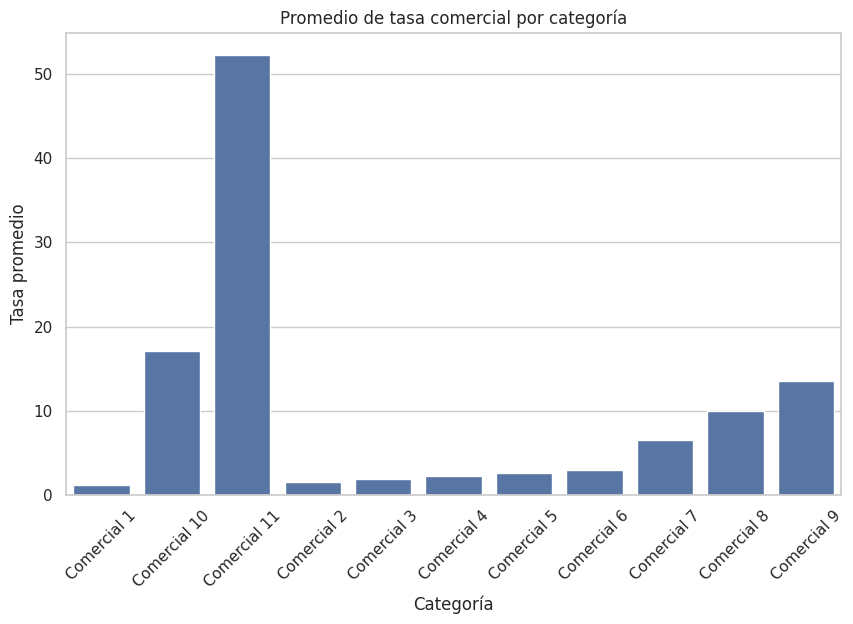

In [ ]:
promedio_comercial = df[df["tipo_tasa"] == "COMERCIAL"].groupby(
    "categoria_comercial"
)["tasa_comercial"].mean().reset_index()

sns.barplot(
    data=promedio_comercial,
    x="categoria_comercial",
    y="tasa_comercial"
)

plt.title("Promedio de tasa comercial por categoría")
plt.xlabel("Categoría")
plt.ylabel("Tasa promedio")

plt.xticks(rotation=45)
plt.show()


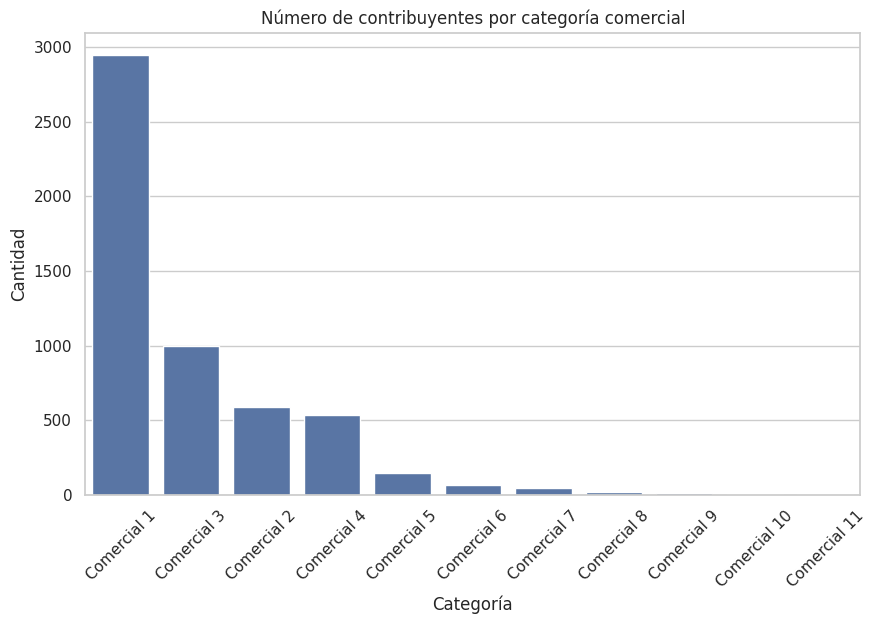

In [ ]:
conteo_comercial = df_comercial["categoria_comercial"].value_counts().reset_index()
conteo_comercial.columns = ["categoria_comercial", "cantidad"]

sns.barplot(
    data=conteo_comercial,
    x="categoria_comercial",
    y="cantidad"
)

plt.title("Número de contribuyentes por categoría comercial")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)
plt.show()

En el caso de los contribuyentes comerciales, se identificó una distribución heterogénea tanto en la cantidad de contribuyentes como en los valores de la tasa. Se observa que las categorías con menor nivel de patrimonio concentran un mayor número de contribuyentes, mientras que las categorías superiores presentan valores más elevados de tasa, evidenciando un comportamiento progresivo en la estructura tarifaria.

Calculamos la tasa de residuos para el urbano 1, urbano 2, urbano 3

In [ ]:
#Filtramos solo los registros de Urbano 1
df_u1 = df[df["tipo_tasa"] == "URBANO 1"].copy()

In [ ]:
df_u1["valor_base_variable"] = 1.27

In [ ]:
#Calculamos el factor de ajuste según avalúo
def calcular_factor_ajuste(row):
    avaluo = row["valor_posesion_avaluo_patrimonio"]

    if avaluo <= 15000:
        return 0.50
    elif avaluo <= 45000:
        return 0.90
    elif avaluo <= 80000:
        return 1.10
    else:
        return 1.50

df_u1["factor_ajuste"] = df_u1.apply(calcular_factor_ajuste, axis=1)

In [ ]:
#Calculamos el valor variable ajustado
df_u1["valor_variable_ajustado"] = (
    df_u1["valor_base_variable"] * df_u1["factor_ajuste"]
).round(2)

In [ ]:
#Calculamos el subsidio
def calcular_subsidio(row):
    v = row["valor_posesion_avaluo_patrimonio"]

    if v <= 15000:
        return 0.70
    elif v <= 45000:
        return 0.50
    elif v <= 80000:
        return 0.30
    else:
        return 0.10
df_u1["porcentaje_subsidio"] = df_u1.apply(calcular_subsidio, axis=1)

In [ ]:
#Calculamos el valor final
df_u1["valor_variable_final"] = (
    df_u1["valor_variable_ajustado"] * (1 - df_u1["porcentaje_subsidio"])
)

In [ ]:
#Calculamos la Tasa final
df_u1["tasa_urbano_1"] = (1.11 + df_u1["valor_variable_final"]).round(2)

In [ ]:
#Verificamos
df_u1[[
    "valor_posesion_avaluo_patrimonio",
    "factor_ajuste",
    "valor_variable_ajustado",
    "porcentaje_subsidio",
    "tasa_urbano_1"
]].head(10)

,valor_posesion_avaluo_patrimonio,factor_ajuste,valor_variable_ajustado,porcentaje_subsidio,tasa_urbano_1
5368,21777.46,0.9,1.14,0.5,1.68
5372,11123.30,0.5,0.64,0.7,1.30
5373,195242.22,1.5,1.90,0.1,2.82
5395,16765.39,0.9,1.14,0.5,1.68
5396,52288.53,1.1,1.40,0.3,2.09
5404,33522.26,0.9,1.14,0.5,1.68
5430,14962.50,0.5,0.64,0.7,1.30
5436,32551.61,0.9,1.14,0.5,1.68
5443,NaN,1.5,1.90,0.1,2.82
5450,23032.57,0.9,1.14,0.5,1.68


In [ ]:
#Calculamos cantidad de predios, recaudación mensual y anual
total_u1 = df_u1.shape[0]
total_u1

7915

In [ ]:
total_mensual_u1 = df_u1["tasa_urbano_1"].sum()
total_mensual_u1

np.float64(15361.490000000002)

In [ ]:
total_anual_u1 = total_mensual_u1 * 12
total_anual_u1

np.float64(184337.88)

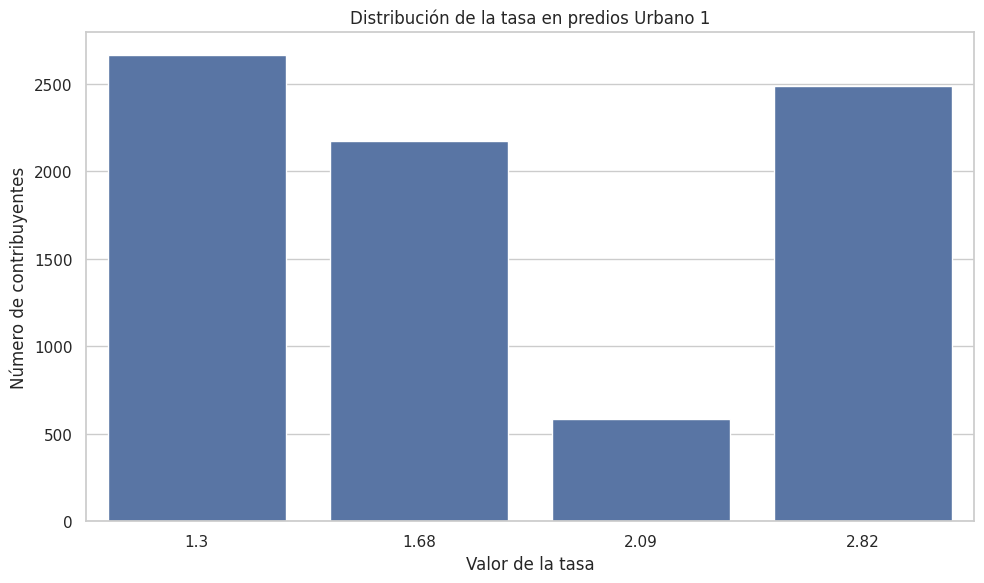

In [ ]:
#Graficamos la distribución de tasas Urbano 1
sns.countplot(
    data=df_u1,
    x="tasa_urbano_1"
)

plt.title("Distribución de la tasa en predios Urbano 1")
plt.xlabel("Valor de la tasa")
plt.ylabel("Número de contribuyentes")

plt.tight_layout()
plt.show()

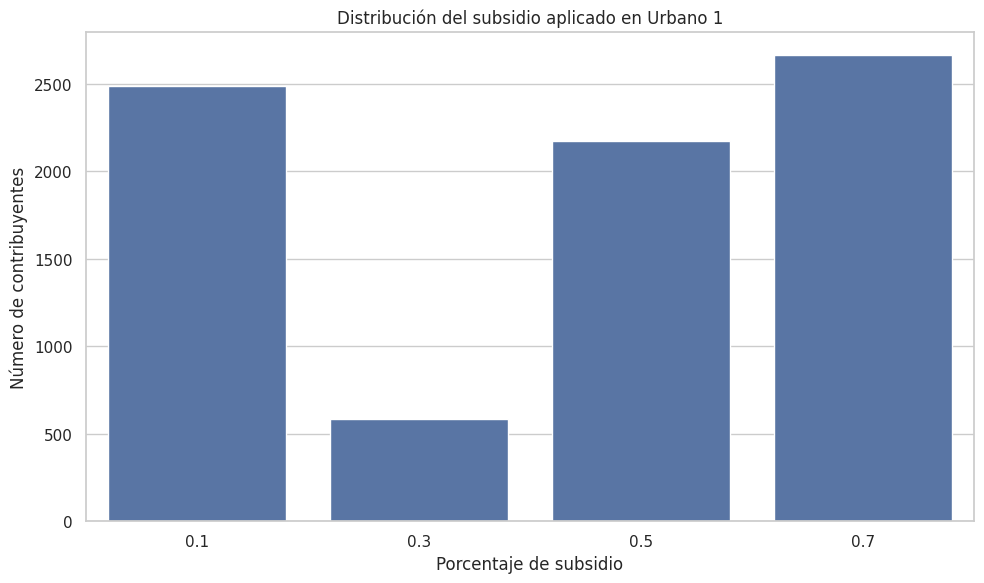

In [ ]:
#Gráfico de subsidio aplicado en Urbano 1
sns.countplot(
    data=df_u1,
    x="porcentaje_subsidio"
)

plt.title("Distribución del subsidio aplicado en Urbano 1")
plt.xlabel("Porcentaje de subsidio")
plt.ylabel("Número de contribuyentes")

plt.tight_layout()
plt.show()

In [ ]:
resumen_subsidio = (
    df_u1["porcentaje_subsidio"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

resumen_subsidio.columns = ["Subsidio", "Porcentaje (%)"]

resumen_subsidio

,Subsidio,Porcentaje (%)
0,0.7,33.67
1,0.1,31.43
2,0.5,27.48
3,0.3,7.42


El análisis del subsidio aplicado en la categoría Urbano 1 evidencia una distribución diferenciada entre los contribuyentes. Se observa una mayor concentración en los niveles de subsidio del 70% y 10%, lo que refleja la aplicación de un esquema progresivo basado en el valor del avalúo. Los contribuyentes con menor capacidad económica reciben mayores niveles de subsidio, mientras que aquellos con mayor patrimonio acceden a porcentajes más bajos, en concordancia con lo establecido en la ordenanza municipal.

Adicionalmente, se calculó la distribución porcentual de los niveles de subsidio, evidenciando la proporción de contribuyentes en cada rango, lo cual permite un análisis más preciso de la política de subsidios aplicada.

Calculamos la tasa del urbano 2

In [ ]:
#Filtramos
df_u2 = df[df["tipo_tasa"] == "URBANO 2"].copy()

In [ ]:
#Valor base
df_u2["valor_base_variable"] = 2.12

In [ ]:
#Factor de ajuste
def calcular_factor_ajuste(row):
    v = row["valor_posesion_avaluo_patrimonio"]

    if pd.isna(v):
        return np.nan
    elif v <= 15000:
        return 0.50
    elif v <= 45000:
        return 0.90
    elif v <= 80000:
        return 1.10
    else:
        return 1.50

df_u2["factor_ajuste"] = df_u2.apply(calcular_factor_ajuste, axis=1)

In [ ]:
#Valor ajustado
df_u2["valor_variable_ajustado"] = (
    df_u2["valor_base_variable"] * df_u2["factor_ajuste"]
).round(2)

In [ ]:
#Subsidio
def calcular_subsidio(row):
    v = row["valor_posesion_avaluo_patrimonio"]

    if pd.isna(v):
        return np.nan
    elif v <= 15000:
        return 0.70
    elif v <= 45000:
        return 0.50
    elif v <= 80000:
        return 0.30
    else:
        return 0.10

df_u2["porcentaje_subsidio"] = df_u2.apply(calcular_subsidio, axis=1)

In [ ]:
#Calculo de la tasa de los residuos urbano 2
df_u2["valor_subsidio"] = (
    df_u2["valor_variable_ajustado"] * df_u2["porcentaje_subsidio"]
).round(2)

df_u2["valor_variable_final"] = (
    df_u2["valor_variable_ajustado"] - df_u2["valor_subsidio"]
).round(2)

In [ ]:
#tasa final
df_u2["tasa_urbano_2"] = (
    1.11 + df_u2["valor_variable_final"]
).round(2)

In [ ]:
#Verificamos
df_u2[[
    "valor_posesion_avaluo_patrimonio",
    "factor_ajuste",
    "valor_variable_ajustado",
    "porcentaje_subsidio",
    "tasa_urbano_2"
]].head(10)

,valor_posesion_avaluo_patrimonio,factor_ajuste,valor_variable_ajustado,porcentaje_subsidio,tasa_urbano_2
5365,6069.41,0.5,1.06,0.7,1.43
5377,31398.86,0.9,1.91,0.5,2.06
5398,8498.09,0.5,1.06,0.7,1.43
5400,32039.91,0.9,1.91,0.5,2.06
5413,0.00,0.5,1.06,0.7,1.43
5420,113030.58,1.5,3.18,0.1,3.97
5421,NaN,NaN,NaN,NaN,NaN
5422,13115.58,0.5,1.06,0.7,1.43
5442,26024.90,0.9,1.91,0.5,2.06
5447,28314.86,0.9,1.91,0.5,2.06


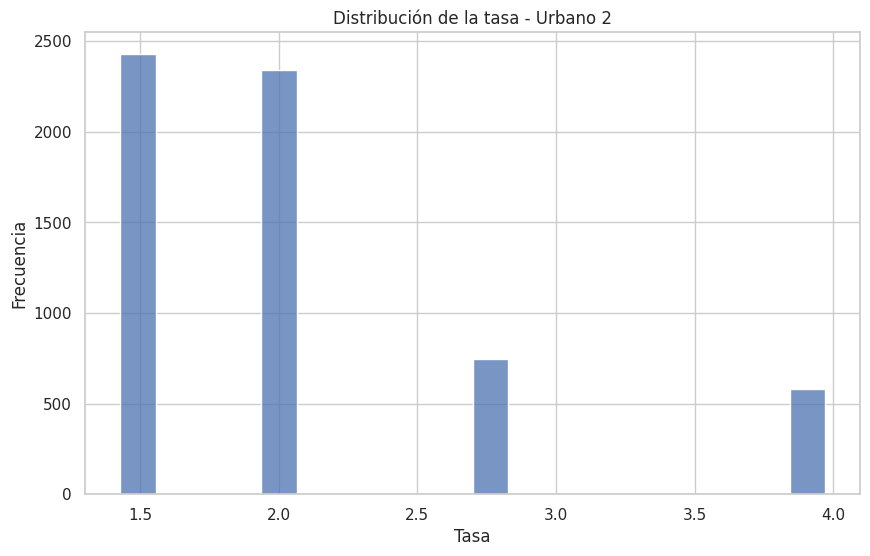

In [ ]:
sns.histplot(
    data=df_u2,
    x="tasa_urbano_2",
    bins=20
)

plt.title("Distribución de la tasa - Urbano 2")
plt.xlabel("Tasa")
plt.ylabel("Frecuencia")

plt.show()

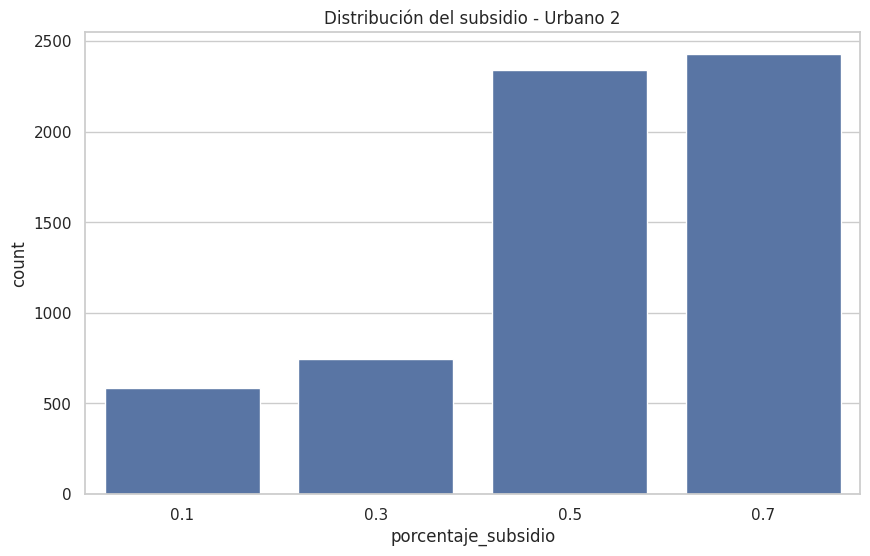

In [ ]:
sns.countplot(
    data=df_u2,
    x="porcentaje_subsidio"
)

plt.title("Distribución del subsidio - Urbano 2")
plt.show()

In [ ]:
total_u2 = df_u2["tasa_urbano_2"].sum()
print("Total mensual Urbano 2:", round(total_u2,2))
print("Total anual Urbano 2:", round(total_u2*12,2))

Total mensual Urbano 2: 12657.85
Total anual Urbano 2: 151894.2


El análisis del subsidio aplicado en la categoría Urbano 2 evidencia una distribución no uniforme entre los contribuyentes. Se observa una mayor concentración en los niveles de subsidio del 70% y 50%, lo que indica que una proporción importante de los predios corresponde a rangos de avalúo medios y bajos. Por otro lado, los niveles de subsidio del 30% y 10% presentan menor cantidad de contribuyentes, lo que refleja una menor presencia de predios con mayor capacidad económica. Este comportamiento confirma la aplicación de un esquema progresivo en la asignación del subsidio, en el cual los contribuyentes con menor avalúo reciben un mayor beneficio, en concordancia con lo establecido en la ordenanza municipal.

Calculo de la tasa de residuos de urbano 3

In [ ]:
#Filtramos
df_u3 = df[df["tipo_tasa"] == "URBANO 3"].copy()

In [ ]:
#Valor base
df_u3["valor_base_variable"] = 13.74

In [ ]:
#Factor de ajuste
def calcular_factor_ajuste(row):
    v = row["valor_posesion_avaluo_patrimonio"]

    if pd.isna(v):
        return np.nan
    elif v <= 15000:
        return 0.50
    elif v <= 45000:
        return 0.90
    elif v <= 80000:
        return 1.10
    else:
        return 1.50

df_u3["factor_ajuste"] = df_u3.apply(calcular_factor_ajuste, axis=1)

In [ ]:
#Valor ajustado aplicamos el redondeo
df_u3["valor_variable_ajustado"] = (
    df_u3["valor_base_variable"] * df_u3["factor_ajuste"]
).round(2)

In [ ]:
#Calculo del Subsidio
def calcular_subsidio_u3(row):
    v = row["valor_posesion_avaluo_patrimonio"]

    if pd.isna(v):
        return np.nan
    elif v <= 15000:
        return 0.95
    elif v <= 45000:
        return 0.90
    elif v <= 80000:
        return 0.85
    else:
        return 0.80

df_u3["porcentaje_subsidio"] = df_u3.apply(calcular_subsidio_u3, axis=1)

In [ ]:
#Valor subsidio
df_u3["valor_subsidio"] = (
    df_u3["valor_variable_ajustado"] * df_u3["porcentaje_subsidio"]
).round(2)

In [ ]:
#Valor final
df_u3["valor_variable_final"] = (
    df_u3["valor_variable_ajustado"] - df_u3["valor_subsidio"]
).round(2)


In [ ]:
#Tasa final
df_u3["tasa_urbano_3"] = (
    1.11 + df_u3["valor_variable_final"]
).round(2)

In [ ]:
df_u3[[
    "valor_posesion_avaluo_patrimonio",
    "factor_ajuste",
    "valor_variable_ajustado",
    "porcentaje_subsidio",
    "tasa_urbano_3"
]].head(10)

,valor_posesion_avaluo_patrimonio,factor_ajuste,valor_variable_ajustado,porcentaje_subsidio,tasa_urbano_3
5367,38874.90,0.9,12.37,0.90,2.35
5369,8582.80,0.5,6.87,0.95,1.45
5371,14042.50,0.5,6.87,0.95,1.45
5376,12325.79,0.5,6.87,0.95,1.45
5381,68603.13,1.1,15.11,0.85,3.38
5397,12216.24,0.5,6.87,0.95,1.45
5399,39625.83,0.9,12.37,0.90,2.35
5407,99275.69,1.5,20.61,0.80,5.23
5446,7417.66,0.5,6.87,0.95,1.45
5464,NaN,NaN,NaN,NaN,NaN


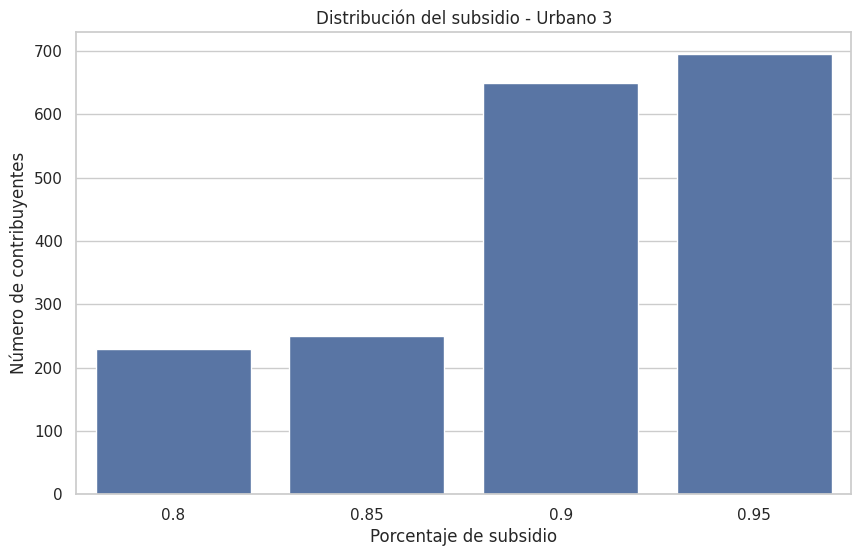

In [ ]:
#Visualizamos
sns.countplot(
    data=df_u3,
    x="porcentaje_subsidio"
)

plt.title("Distribución del subsidio - Urbano 3")
plt.xlabel("Porcentaje de subsidio")
plt.ylabel("Número de contribuyentes")

plt.show()

In [ ]:
# Verificamos las categorías existentes en el dataset
df["categoria"].value_counts()

,count
categoria,
RESIDENCIAL RURAL,33996
RESIDENCIAL URBANO 1,7915
RESIDENCIAL URBANO 2,7040
COMERCIAL,5363
RESIDENCIAL URBANO 3,2036


Calculamos la tasa para la catgoria comercial esta tasa aplica para las impresas medianas y grandes o para indrustrias

In [ ]:
sbu = 470

In [ ]:
#Este cálculo se incluye como referencia de la ordenanza, sin embargo, en el dataset actual no existen registros industriales.
def calcular_tasa_industrial(row):

    #Verificamos si el contribuyente es industrial
    if row["tipo_tasa"] != "INDUSTRIAL":
        return None

    #Obtenemos el patrimonio
    v = row["valor_posesion_avaluo_patrimonio"]

    if pd.isna(v):
        return None

    #Asignamos porcentaje según la ordenanza
    if v <= 500000:
        porcentaje = 15.0  # Industrial 1
    else:
        porcentaje = 30.0  # Industrial 2

    #Aplicamos la fórmula basada en el SBU
    tasa = sbu * (porcentaje / 100)

    return round(tasa, 2)

#Creamos la columna
df["tasa_industrial"] = df.apply(calcular_tasa_industrial, axis=1)

Calculo de tasa categoria otros, esta se usara para eventos públicos

In [ ]:
#Esta categoría no se encuentra en el dataset actual, pero se deja implementada para posibles escenarios futuros.
sbu = 470
def calcular_tasa_otros(row):

    if row["tipo_tasa"] != "OTROS":
        return None

    area = row["area_m2"]

    if pd.isna(area):
        return None

    if area <= 10000:
        porcentaje_sbu = 0.005
    else:
        porcentaje_sbu = 0.003

    tasa_m2 = sbu * (porcentaje_sbu / 100)
    tasa_total = tasa_m2 * area

    return round(tasa_total, 2)

In [ ]:
#Pasamos las tasas urbanas calculadas al dataframe principal
df.loc[df_u1.index, "tasa_urbano_1"] = df_u1["tasa_urbano_1"]
df.loc[df_u2.index, "tasa_urbano_2"] = df_u2["tasa_urbano_2"]
df.loc[df_u3.index, "tasa_urbano_3"] = df_u3["tasa_urbano_3"]

In [ ]:
df["tasa_calculada"] = np.select(
    [
        df["tipo_tasa"] == "RURAL",
        df["tipo_tasa"] == "COMERCIAL",
        df["tipo_tasa"] == "URBANO 1",
        df["tipo_tasa"] == "URBANO 2",
        df["tipo_tasa"] == "URBANO 3"
    ],
    [
        df["tasa_rural"],
        df["tasa_comercial"],
        df["tasa_urbano_1"],
        df["tasa_urbano_2"],
        df["tasa_urbano_3"]
    ],
    default=np.nan
)

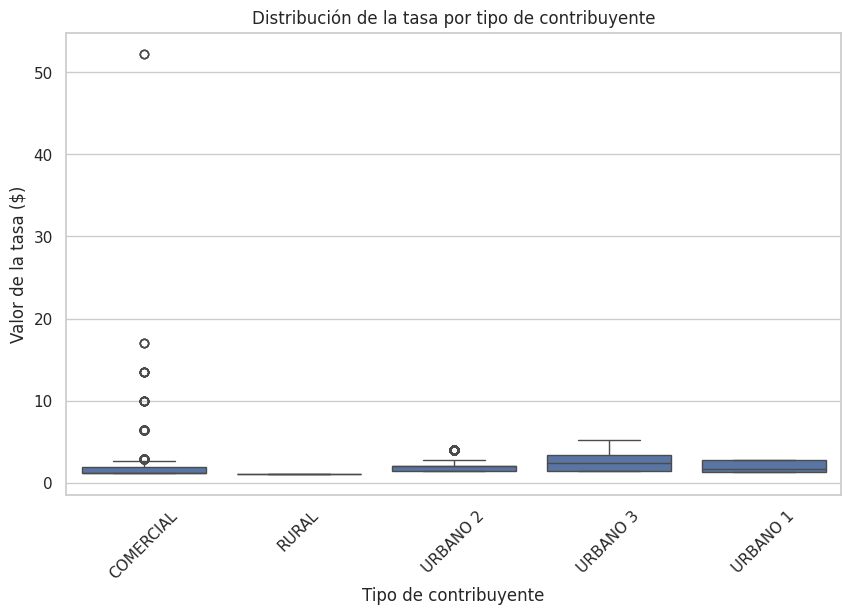

In [ ]:
sns.boxplot(data=df, x="tipo_tasa", y="tasa_calculada")
plt.title("Distribución de la tasa por tipo de contribuyente")
plt.xlabel("Tipo de contribuyente")
plt.ylabel("Valor de la tasa ($)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Creamos la tabla de recaudación
recaudacion = df.groupby("tipo_tasa")["tasa_calculada"].sum().reset_index()

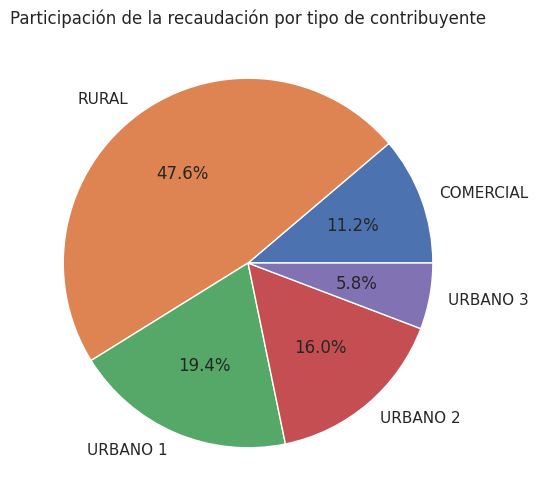

In [ ]:
recaudacion.set_index("tipo_tasa")["tasa_calculada"].plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Participación de la recaudación por tipo de contribuyente")
plt.ylabel("")

plt.show()

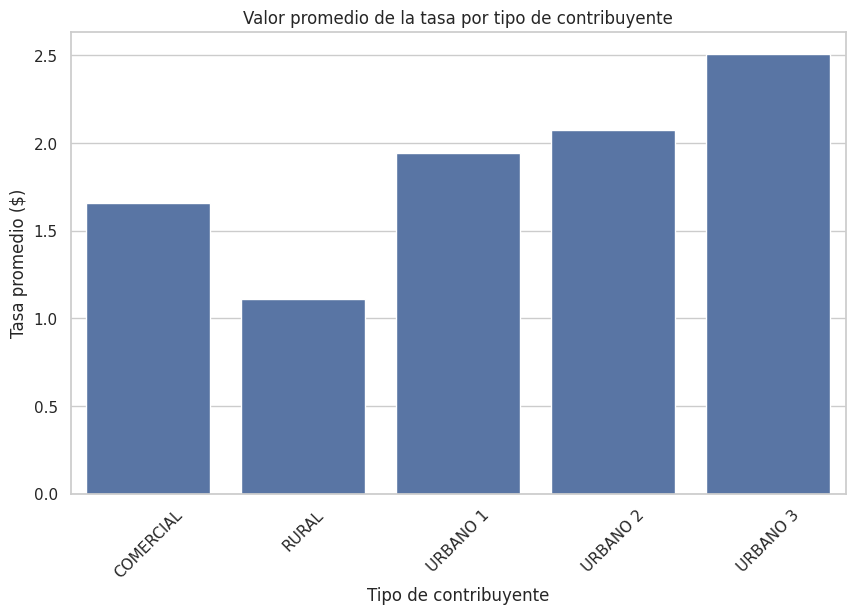

In [ ]:
promedio = df.groupby("tipo_tasa")["tasa_calculada"].mean().reset_index()

sns.barplot(data=promedio, x="tipo_tasa", y="tasa_calculada")

plt.title("Valor promedio de la tasa por tipo de contribuyente")
plt.xlabel("Tipo de contribuyente")
plt.ylabel("Tasa promedio ($)")
plt.xticks(rotation=45)

plt.show()

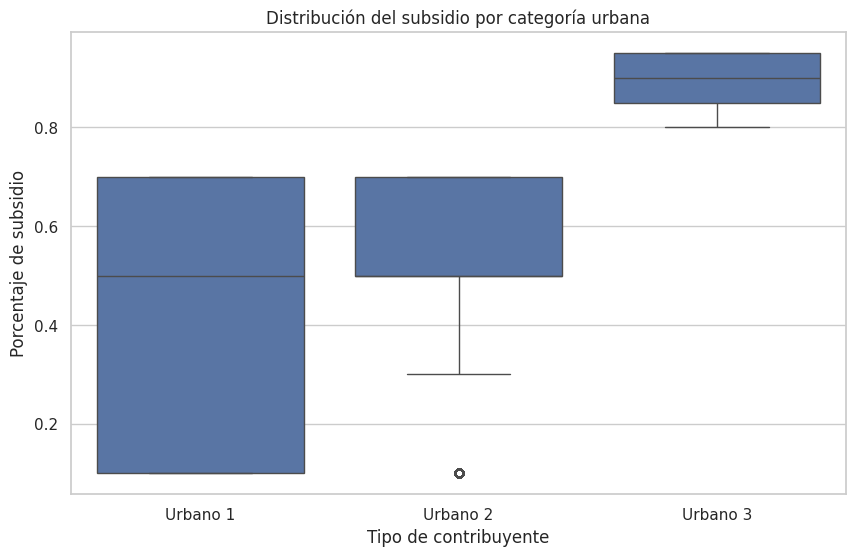

In [ ]:
#Unimos subsidios de los urbanos
df_subsidio = pd.concat([
    df_u1[["porcentaje_subsidio"]].assign(tipo="Urbano 1"),
    df_u2[["porcentaje_subsidio"]].assign(tipo="Urbano 2"),
    df_u3[["porcentaje_subsidio"]].assign(tipo="Urbano 3")
])

sns.boxplot(data=df_subsidio, x="tipo", y="porcentaje_subsidio")

plt.title("Distribución del subsidio por categoría urbana")
plt.xlabel("Tipo de contribuyente")
plt.ylabel("Porcentaje de subsidio")

plt.show()

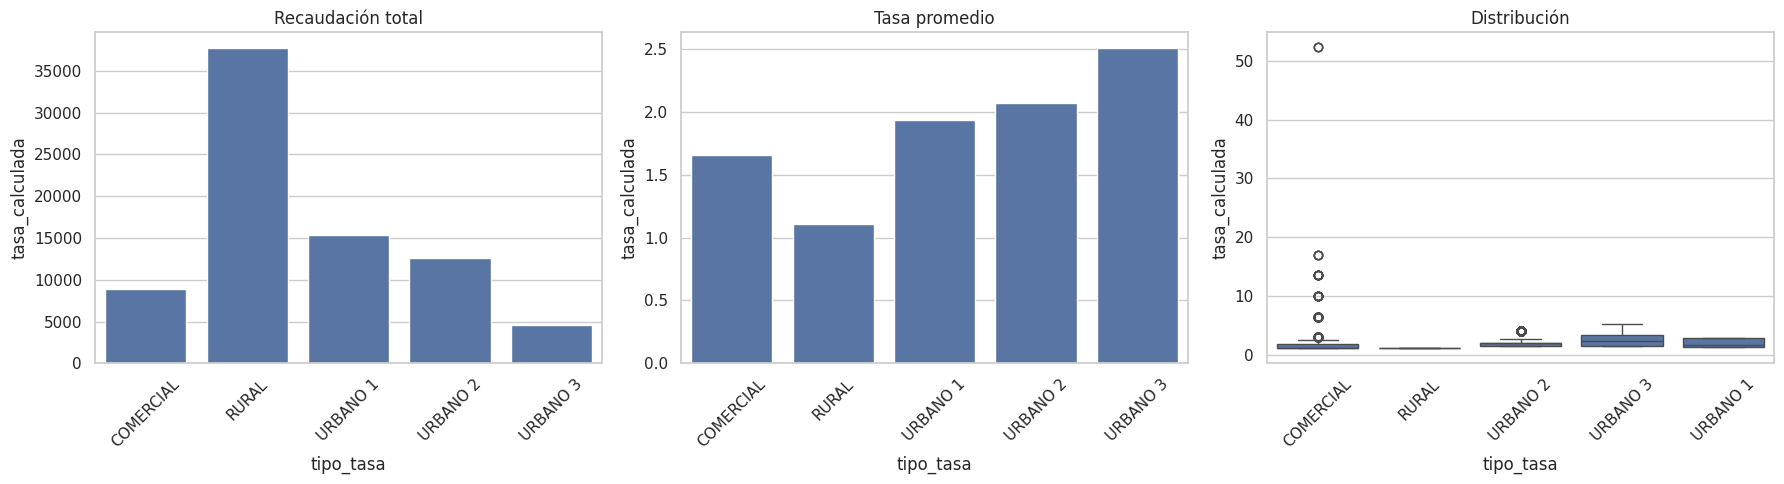

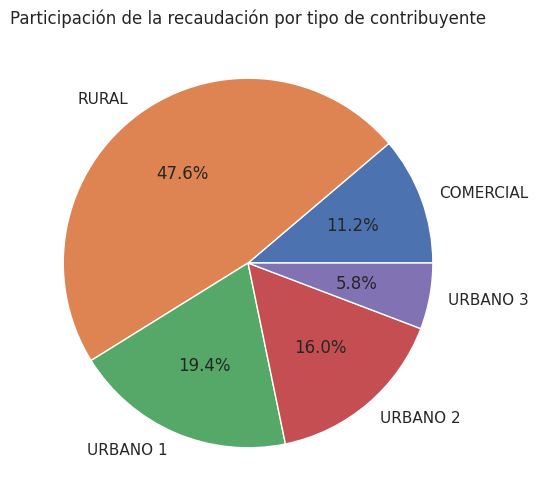

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Calculate recaudacion (total collection)
recaudacion = df.groupby("tipo_tasa")["tasa_calculada"].sum().reset_index()

# Recaudación
sns.barplot(data=recaudacion, x="tipo_tasa", y="tasa_calculada", ax=axs[0])
axs[0].set_title("Recaudación total")

# Promedio
sns.barplot(data=promedio, x="tipo_tasa", y="tasa_calculada", ax=axs[1])
axs[1].set_title("Tasa promedio")

# Distribución
sns.boxplot(data=df, x="tipo_tasa", y="tasa_calculada", ax=axs[2])
axs[2].set_title("Distribución")

for ax in axs:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Pie chart for recaudacion (moved from a previous cell)
recaudacion.set_index("tipo_tasa")["tasa_calculada"].plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Participación de la recaudación por tipo de contribuyente")
plt.ylabel("")

plt.show()

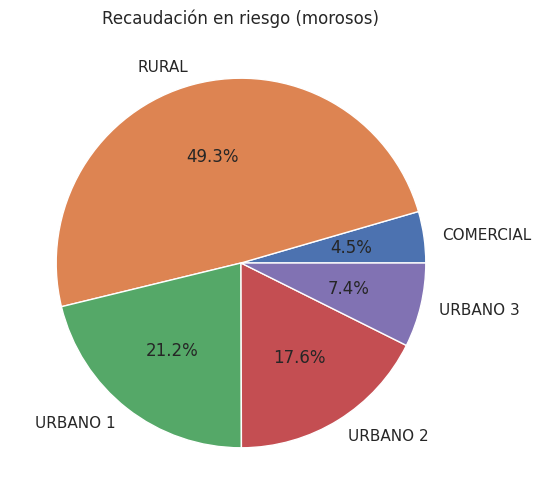

In [ ]:
#recaudacion_morosos = df[df["moroso_2025"] == 1] \
    .groupby("tipo_tasa")["tasa_calculada"].sum()

recaudacion_morosos.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Recaudación en riesgo (morosos)")
plt.ylabel("")

plt.show()

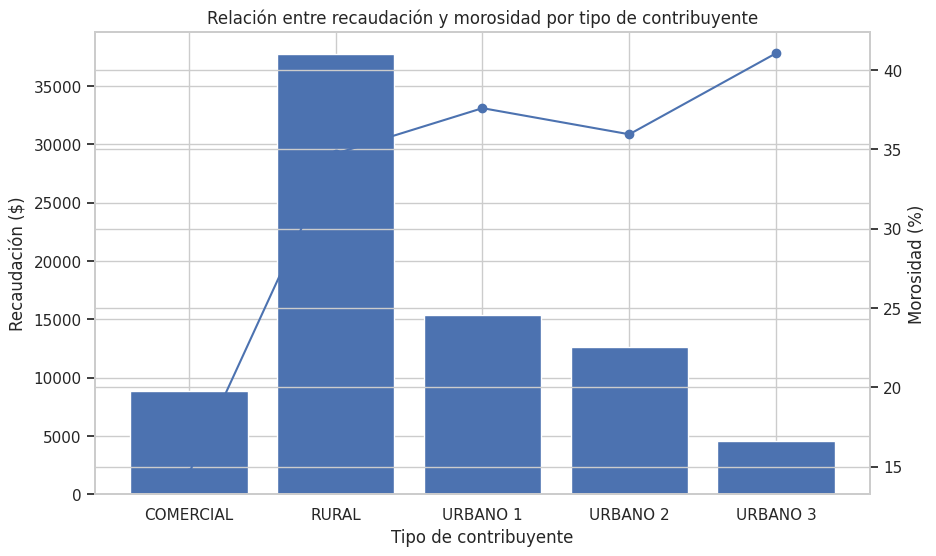

In [ ]:
#RECAUDACIÓN vs MOROSIDAD POR CATEGORÍA
recaudacion = df.groupby("tipo_tasa")["tasa_calculada"].sum()

#Morosidad promedio (%)
morosidad = df.groupby("tipo_tasa")["moroso_2025"].mean() * 100

#Unimos en un solo dataframe
analisis = pd.DataFrame({
    "recaudacion": recaudacion,
    "morosidad_%": morosidad
}).reset_index()

#Creamos gráfico con dos ejes
fig, ax1 = plt.subplots()

#Barras de recaudación
ax1.bar(analisis["tipo_tasa"], analisis["recaudacion"])
ax1.set_ylabel("Recaudación ($)")
ax1.set_xlabel("Tipo de contribuyente")

#Línea de morosidad
ax2 = ax1.twinx()
ax2.plot(analisis["tipo_tasa"], analisis["morosidad_%"], marker='o')
ax2.set_ylabel("Morosidad (%)")

plt.title("Relación entre recaudación y morosidad por tipo de contribuyente")
plt.xticks(rotation=45)

plt.show()

El análisis conjunto de la recaudación y la morosidad por tipo de contribuyente permite identificar tanto la capacidad de generación de ingresos como el nivel de riesgo asociado a cada categoría. Se observa que la categoría rural concentra la mayor recaudación total, lo cual se explica principalmente por el alto número de contribuyentes en este segmento. Sin embargo, esta misma categoría presenta niveles de morosidad relativamente elevados, lo que implica que una parte significativa de estos ingresos podría no materializarse efectivamente.

Por otro lado, las categorías urbanas muestran un comportamiento intermedio: generan ingresos importantes y presentan niveles de morosidad moderados, destacando Urbano 3 como la categoría con mayor porcentaje de morosidad, aunque con menor contribución a la recaudación total. En el caso de la categoría comercial, se evidencia una menor participación en la recaudación, acompañada de un nivel de morosidad más bajo en comparación con otras categorías.

En conjunto, estos resultados evidencian que las categorías con mayor aporte económico no necesariamente representan ingresos seguros, siendo fundamental considerar la morosidad como un factor clave en la gestión financiera municipal. Este análisis permite identificar segmentos críticos donde se deben enfocar estrategias de cobranza y control para mejorar la eficiencia recaudatoria.

In [ ]:
#Guardamos el dataset con la tasa calculada
ruta_guardado = "/content/drive/MyDrive/TFM/dataset_con_tasas.csv"
df.to_csv(ruta_guardado, index=False)

In [ ]:
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025',
       'dias_hasta_pago_2023', 'dias_hasta_pago_2024', 'dias_hasta_pago_2025',
       'estado_pago_2023', 'estado_pago_2024', 'estado_pago_2025',
       'moroso_2023', 'moroso_2024', 'moroso_2025', 'anio', 'tipo_tasa',
       'tasa_rural', 'categoria_comercial', 'porcentaje_sbu_comercial',
       'tasa_comercial', 'tasa_industrial', 'tasa_urbano_1', 'tasa_urbano_2',
       'tasa_urbano_3', 'tasa_calculada'],
      dtype='object')